In [2]:
import fwiVis.fwiVis as fv
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from geocube.api.core import make_geocube
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 

# Choose a fire

Fires aren't mapped onto MBTS or NIFC fire names, so the fireID that the FEDS algorithm generates is a number. If I am interested in a specific fire, I look at a late-season snapshot file that should contain that fire, and I figure out the ID from that. 

In [25]:
snap = fv.prep_gdf(date = '20191031PM',handle_multi=False,only_lf=True,area_lim=5)
#snap.explore()

/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:607: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_test['lon'] = gdf_test.centroid.x
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:608: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_test['lat'] = gdf_test.centroid.y


In [26]:
## Load up that fire 
fireID = '9987'
gdf = fv.load_large_fire(fireID)

['F9987']


/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:695: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['lon'] = gdf.centroid.x
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:696: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['lat'] = gdf.centroid.y


## Gridded FWI Products

There are a few gridded FWI products that exist. To see them all listed (plus a few more EIS datasets), we can look at the contents of this folder. In it there is a FWI-GEOS-5 with hourly resolution, one with daily resolution, and forecast datasets. 

In [67]:
s3.ls("s3://veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/") # This isn;t working # Gridded FWI products are stored here. 

['veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/forecast',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/lat',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/lon',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/time']

In [68]:
s3.ls("s3://veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/") # This is working 

['veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/.zattrs',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/.zgroup',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/.zmetadata',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/GEOS-5_BUI',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/GEOS-5_DC',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/GEOS-5_DMC',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/GEOS-5_DSR',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/GEOS-5_FFMC',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/GEOS-5_FWI',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/GEOS-5_ISI',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/forecast',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/lat',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/lon',
 'veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/time']

We can read in the dataset we are most interested in. Here I read in the "daily" resolution product.

In [69]:
#imerge = xr.open_dataset("s3://veda-data-store-staging/EIS/zarr/GEOS5_FWI_GPM_LATE_v5_Daily.zarr", engine="zarr")
#imerge = xr.open_dataset("s3://veda-data-store-staging/EIS/zarr/FWI.GEOS-5.zarr/", engine="zarr")
imerge = xr.open_dataset("s3://veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/", engine="zarr")

imerge.rio.write_crs("epsg:4326", inplace=True)
imerge.rio.set_spatial_dims(x_dim = "lon", y_dim = "lat", inplace = True)
imerge

<xarray.Dataset>
Dimensions:      (forecast: 9, time: 2409, lat: 533, lon: 1152)
Coordinates:
  * forecast     (forecast) int64 0 1 2 3 4 5 6 7 8
  * lat          (lat) float64 -58.0 -57.75 -57.5 -57.25 ... 74.5 74.75 75.0
  * lon          (lon) float64 -180.0 -179.7 -179.4 -179.1 ... 179.1 179.4 179.7
  * time         (time) datetime64[ns] 2018-01-01 2018-01-02 ... 2024-08-05
    spatial_ref  int64 0
Data variables:
    GEOS-5_BUI   (forecast, time, lat, lon) float32 ...
    GEOS-5_DC    (forecast, time, lat, lon) float32 ...
    GEOS-5_DMC   (forecast, time, lat, lon) float32 ...
    GEOS-5_DSR   (forecast, time, lat, lon) float32 ...
    GEOS-5_FFMC  (forecast, time, lat, lon) float32 ...
    GEOS-5_FWI   (forecast, time, lat, lon) float32 ...
    GEOS-5_ISI   (forecast, time, lat, lon) float32 ...
Attributes: (12/46)
    Center:              NASA GISS / Columbia University
    Center::             center
    DCDryStartFactor:    5.0
    DCDryStartFactor::   DC number of days since precip mult factor for dry s...
    DCStart:             15.0
    DCStart::            DC starting value after wet winter
    ...                  ...
    snowCoverDaysCalc:   60.0
    snowCoverDaysCalc::  Number of days prior to spring over which to determi...
    startShutDays:       2.0
    startShutDays::      Number of previous days over which to consider start...
    tempThresh:          6.0
    tempThresh::         Temp thresh (C) to define start and end of winter

**Subset to a specific fire**

In [70]:
#  -79.487003,37.917099,-75.050636,39.722842


test_clip =  imerge.rio.clip_box(minx = -79.487003, miny = 37.917099, maxx=-75.050636, maxy = 39.722842, auto_expand= True)
test_clip

<xarray.Dataset>
Dimensions:      (forecast: 9, lat: 8, lon: 15, time: 2409)
Coordinates:
  * forecast     (forecast) int64 0 1 2 3 4 5 6 7 8
  * lat          (lat) float64 38.0 38.25 38.5 38.75 39.0 39.25 39.5 39.75
  * lon          (lon) float64 -79.38 -79.06 -78.75 ... -75.62 -75.31 -75.0
  * time         (time) datetime64[ns] 2018-01-01 2018-01-02 ... 2024-08-05
    spatial_ref  int64 0
Data variables:
    GEOS-5_BUI   (forecast, time, lat, lon) float32 ...
    GEOS-5_DC    (forecast, time, lat, lon) float32 ...
    GEOS-5_DMC   (forecast, time, lat, lon) float32 ...
    GEOS-5_DSR   (forecast, time, lat, lon) float32 ...
    GEOS-5_FFMC  (forecast, time, lat, lon) float32 ...
    GEOS-5_FWI   (forecast, time, lat, lon) float32 ...
    GEOS-5_ISI   (forecast, time, lat, lon) float32 ...
Attributes: (12/46)
    Center:              NASA GISS / Columbia University
    Center::             center
    DCDryStartFactor:    5.0
    DCDryStartFactor::   DC number of days since precip mult factor for dry s...
    DCStart:             15.0
    DCStart::            DC starting value after wet winter
    ...                  ...
    snowCoverDaysCalc:   60.0
    snowCoverDaysCalc::  Number of days prior to spring over which to determi...
    startShutDays:       2.0
    startShutDays::      Number of previous days over which to consider start...
    tempThresh:          6.0
    tempThresh::         Temp thresh (C) to define start and end of winter

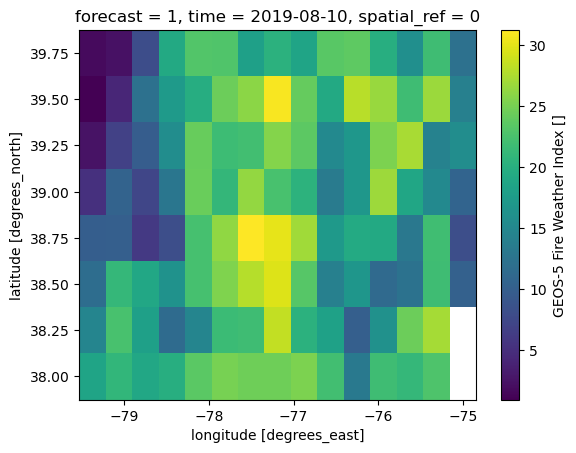

In [71]:
test_clip["GEOS-5_FWI"].sel(time = "2019-08-10", forecast = 1).plot()

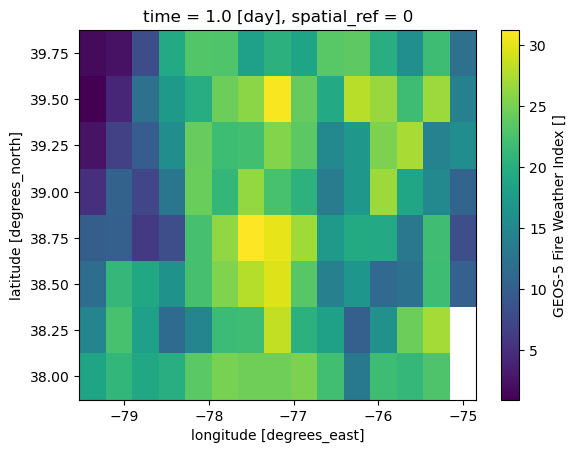

In [72]:
# Donloaded from https://portal.nccs.nasa.gov/datashare/GlobalFWI/v2.0/fwiCalcs.GEOS-5/Default/GEOS-5/2019/2019081000/FWI.GEOS-5.Daily.Default.2019081000.20190811.nc
ncdf = xr.open_dataset("/projects/old_shared/fire_weather_vis/FWI.GEOS-5.Daily.Default.2019081000.20190811.nc", engine="netcdf4")
ncdf.rio.write_crs("epsg:4326", inplace=True)
ncdf.rio.set_spatial_dims(x_dim = "lon", y_dim = "lat", inplace = True)
ncdf

ncdf = ncdf.rio.clip_box(minx = -79.487003, miny = 37.917099, maxx=-75.050636, maxy = 39.722842, auto_expand= True)

ncdf["GEOS-5_FWI"].plot()

In [76]:
final_perimeter = max(gdf[gdf.t == max(gdf.t)].geometry) ## Get the final perimeter of a fire. 
lons = final_perimeter.envelope.exterior.coords.xy[0]
lats = final_perimeter.envelope.exterior.coords.xy[1]

img_clip = imerge.rio.clip_box(minx = min(lons), miny = min(lats), maxx=max(lons), maxy = max(lats), auto_expand= True) # Clip by space
#img_clip = img_clip.sel(time = slice(min(gdf.t), max(gdf.t))).mean(dim = ["lat", "lon"]) ## Clip by time

#img_clip["GEOS-5_FWI"].sel(forecast = 0).plot()
img_clip

<xarray.Dataset>
Dimensions:      (forecast: 9, lat: 2, lon: 2, time: 2409)
Coordinates:
  * forecast     (forecast) int64 0 1 2 3 4 5 6 7 8
  * lat          (lat) float64 38.5 38.75
  * lon          (lon) float64 -122.8 -122.5
  * time         (time) datetime64[ns] 2018-01-01 2018-01-02 ... 2024-08-05
    spatial_ref  int64 0
Data variables:
    GEOS-5_BUI   (forecast, time, lat, lon) float32 ...
    GEOS-5_DC    (forecast, time, lat, lon) float32 ...
    GEOS-5_DMC   (forecast, time, lat, lon) float32 ...
    GEOS-5_DSR   (forecast, time, lat, lon) float32 ...
    GEOS-5_FFMC  (forecast, time, lat, lon) float32 ...
    GEOS-5_FWI   (forecast, time, lat, lon) float32 ...
    GEOS-5_ISI   (forecast, time, lat, lon) float32 ...
Attributes: (12/46)
    Center:              NASA GISS / Columbia University
    Center::             center
    DCDryStartFactor:    5.0
    DCDryStartFactor::   DC number of days since precip mult factor for dry s...
    DCStart:             15.0
    DCStart::            DC starting value after wet winter
    ...                  ...
    snowCoverDaysCalc:   60.0
    snowCoverDaysCalc::  Number of days prior to spring over which to determi...
    startShutDays:       2.0
    startShutDays::      Number of previous days over which to consider start...
    tempThresh:          6.0
    tempThresh::         Temp thresh (C) to define start and end of winter

I also have a pre-written function for subsetting to a specific fire & merging the output. 

In [7]:
sub_imerge = fv.imerge_merge(fireID, year = "2019", path_region = "WesternUS", add_anomolies = False)
sub_imerge

/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:426: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['lon'] = gdf.centroid.x
/projects/old_shared/fire_weather_vis/base-fwi-vis/fwiVis/fwiVis.py:427: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['lat'] = gdf.centroid.y


(array('d', [-122.84407979187542, -122.60267863867738, -122.60267863867738, -122.84407979187542, -122.84407979187542]), array('d', [38.534916213631334, 38.534916213631334, 38.82353999355528, 38.82353999355528, 38.534916213631334]))


,n_pixels,n_newpixels,farea,fperim,flinelen,duration,pixden,meanFRP,t,geometry,lon,lat,fireID,GPM.LATE.v5_BUI,GPM.LATE.v5_DC,GPM.LATE.v5_DMC,GPM.LATE.v5_DSR,GPM.LATE.v5_FFMC,GPM.LATE.v5_FWI,GPM.LATE.v5_ISI
0,1466,282,280.802135,98.108137,45.155644,3.5,5.220758,25.320177,2019-10-27 12:00:00,"POLYGON ((-122.81710 38.76604, -122.81710 38.7...",-122.719815,38.696418,9987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1184,544,187.421563,64.983287,31.665822,3.0,6.317309,38.425441,2019-10-27 00:00:00,"POLYGON ((-122.81716 38.76588, -122.81711 38.7...",-122.735554,38.728194,9987,493.698853,1235.621216,451.551361,67.311501,96.263023,80.802963,32.735844
2,338,338,70.270270,38.070108,33.909390,0.0,4.810000,36.312811,2019-10-24 00:00:00,"POLYGON ((-122.82081 38.73546, -122.81725 38.7...",-122.761216,38.753575,9987,484.263153,1221.052490,441.903198,43.043644,97.592751,63.917141,21.357096
3,640,29,113.878165,50.282419,4.244982,2.5,5.620041,72.725517,2019-10-26 12:00:00,"POLYGON ((-122.81954 38.75747, -122.81954 38.7...",-122.750142,38.758082,9987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,611,108,112.017163,50.033462,14.498416,2.0,5.454521,5.148981,2019-10-26 00:00:00,"POLYGON ((-122.81953 38.75731, -122.81954 38.7...",-122.751402,38.758507,9987,491.643890,1232.206177,449.464020,29.196070,97.470146,51.503559,14.941766
5,456,50,87.192550,43.891569,11.919409,1.0,5.229805,3.479200,2019-10-25 00:00:00,"POLYGON ((-122.81921 38.75355, -122.81924 38.7...",-122.763663,38.758232,9987,488.121216,1226.772339,445.860321,29.625044,97.684486,51.958572,15.142368
6,503,47,91.962610,45.590540,8.320518,1.5,5.469614,49.576170,2019-10-25 12:00:00,"POLYGON ((-122.81924 38.75373, -122.81953 38.7...",-122.761565,38.759738,9987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,406,68,80.196451,42.282303,16.776737,0.5,5.062568,14.043235,2019-10-24 12:00:00,"POLYGON ((-122.81737 38.74534, -122.81921 38.7...",-122.763658,38.754596,9987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1682,216,328.046566,96.826439,30.774894,4.0,5.127321,5.607361,2019-10-28 00:00:00,"POLYGON ((-122.81710 38.76605, -122.81708 38.7...",-122.715676,38.682686,9987,496.166626,1239.443237,454.088013,24.055107,96.554169,46.211880,12.554485
9,1702,20,329.019411,95.929187,3.301761,4.5,5.172947,23.774500,2019-10-28 12:00:00,"POLYGON ((-122.81708 38.76610, -122.81703 38.7...",-122.715521,38.682490,9987,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Look up weather station FWI for fires

In [16]:
## Load up helper objects

files = s3.ls("s3://veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/FWI/") # This will update through time. Not nessisary now because focus on 2019
st_id_map = pd.read_csv("/projects/my-public-bucket/fire_weather_vis/ref_data/isd-history.csv") ## For mappting ID's to lat lon

# Helper Variable
stations = fv.st_avail(files, st_id_map = st_id_map)
st_dict = stations[['Lat', 'Lon']].to_dict('records')
#stations

AttributeError: 's3.ServiceResource' object has no attribute 'ls'

In [33]:
s3.ls("s3://veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/FWI")

#read_me = pd.read_table("s3://veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/README.DailyHourlyFWI.txt")
# import boto3
# s3 = boto3.resource('s3')
# bucket = s3.Bucket("s3://veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/README.DailyHourlyFWI.txt")
# # Iterates through all the objects, doing the pagination for you. Each obj
# # is an ObjectSummary, so it doesn't contain the body. You'll need to call
# # get to get the whole body.
# for obj in bucket.objects.all():
#     key = obj.key
#     body = obj.get()['Body'].read()
#print(*read_me.iloc[5])

In [42]:
s3.ls("s3://veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/FWI")

['veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/FWI/._722430-12960.spline.HourlyFWIFromHourlyInterpContinuous.csv',
 'veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/FWI/722400-03937.spline.DailyFWIfromHourlyInterp.csv',
 'veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/FWI/722400-03937.spline.HourlyFWIFromHourlyInterpContinuous.csv',
 'veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/FWI/722400-03937.spline.HourlyFWIFromHourlyInterpWithNoonRestart.csv',
 'veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/FWI/722410-12917.spline.DailyFWIfromHourlyInterp.csv',
 'veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/FWI/722410-12917.spline.HourlyFWIFromHourlyInterpContinuous.csv',
 'veda-data-store-staging/EIS/other/station-FWI/20000101.20220925.hrlyInterp/FWI/722410-12917.spline.HourlyFWIFromHourlyInterpWithNoonRestart.csv',
 'veda-da

In [9]:
## Get Fire of interest lat and lon 

foi = gdf
foi = foi.rename(columns = {"lat": "Lat", "lon": "Lon"})
foi = foi.iloc[0] # First element

## Look for closest station
st_cls = fv.closest(st_dict, foi)

## Get station Data
st = fv.get_st(lat = st_cls["Lat"], lon = st_cls["Lon"], stations = stations)

## Merge with fire data

full_fr = fv.fr_st_merge(gdf, st, sub = True)
full_fr = full_fr.sort_values(by = ["t"])

**Diagnisitc Station Plotting**

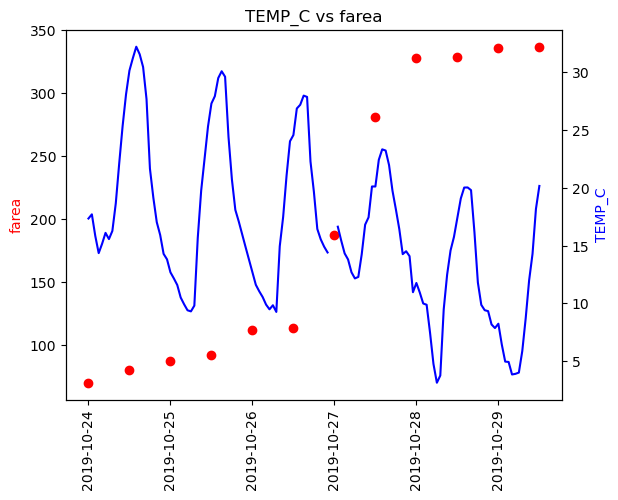

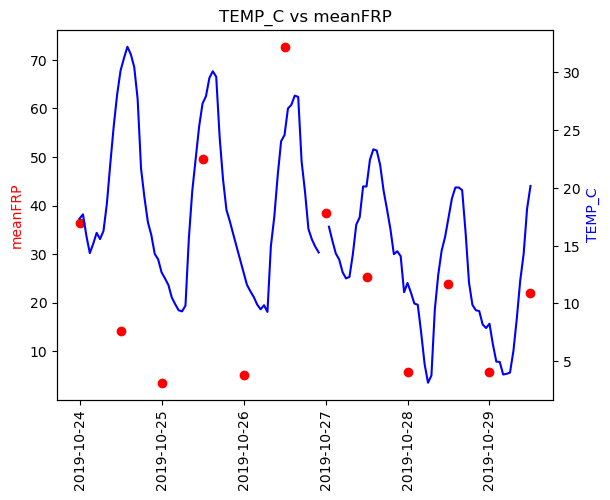

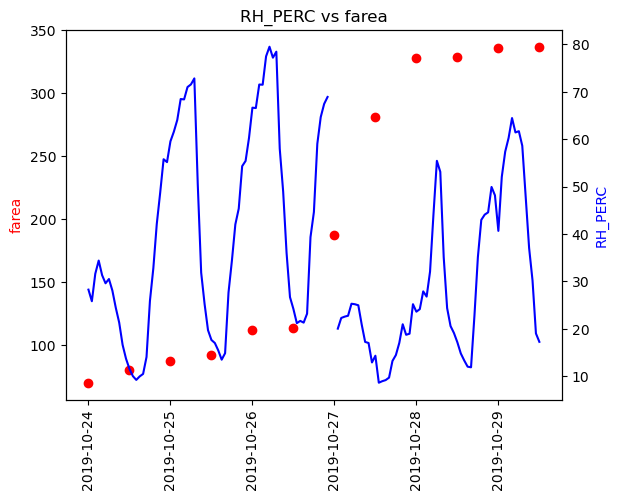

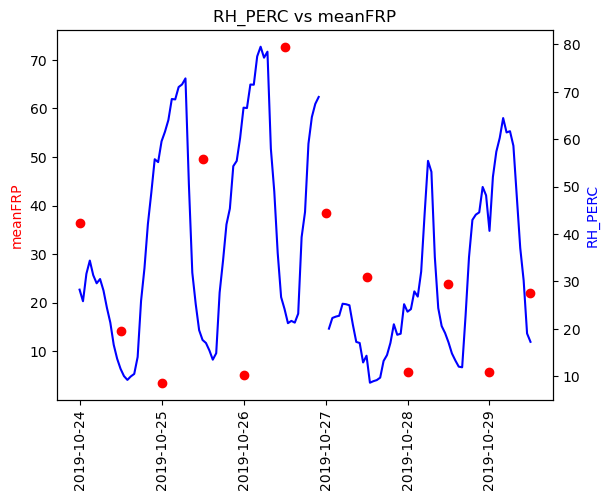

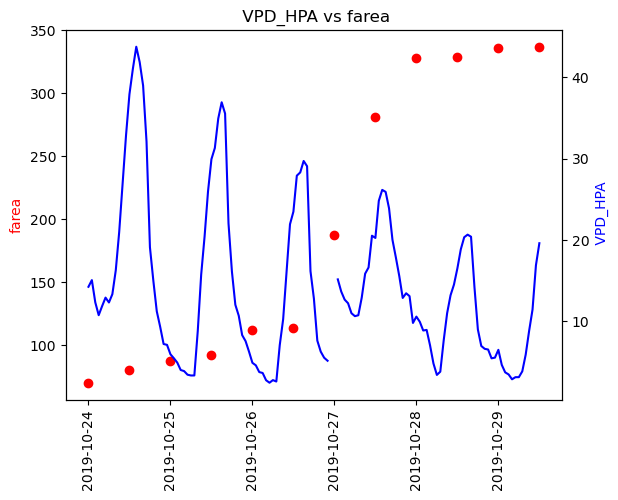

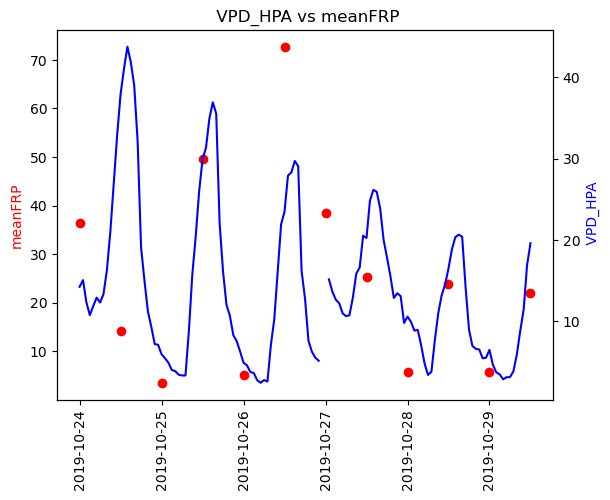

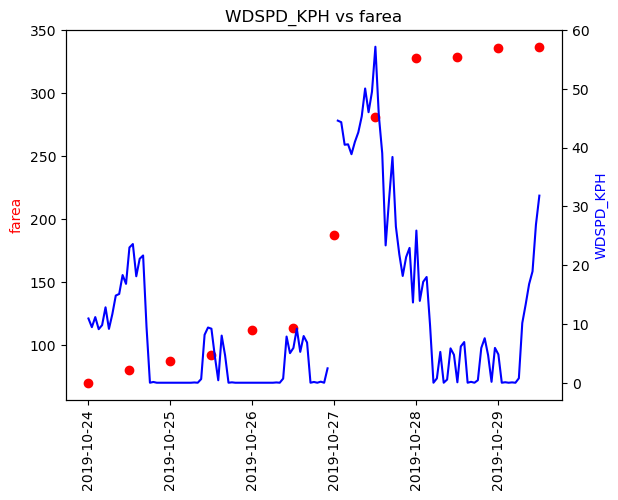

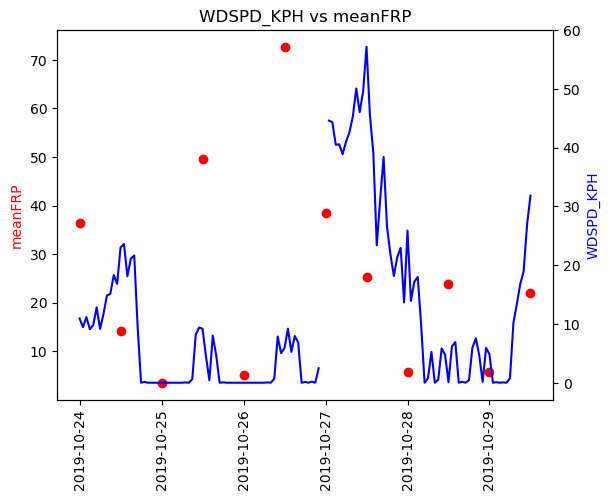

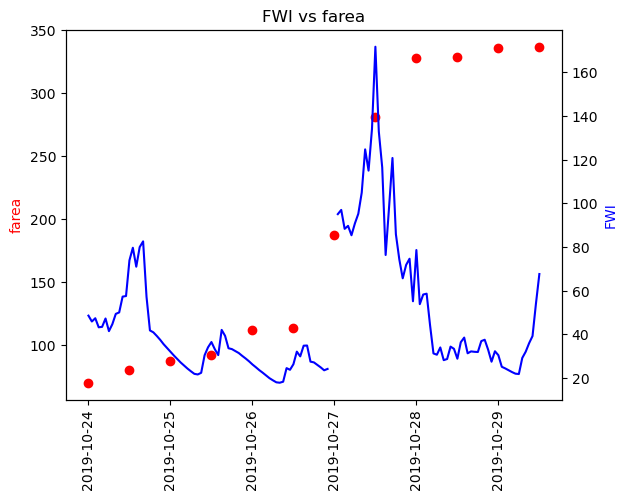

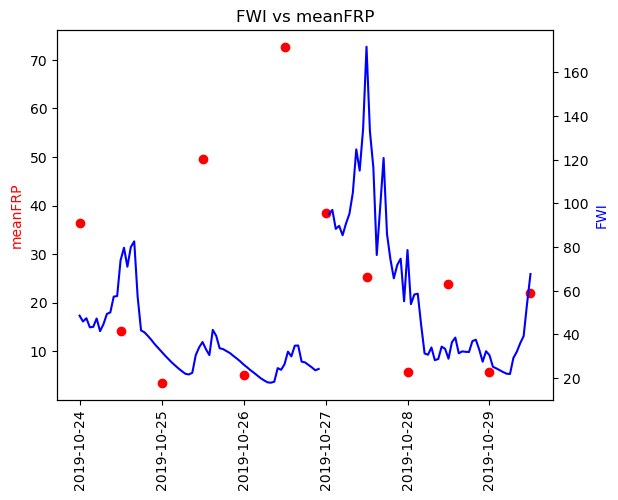

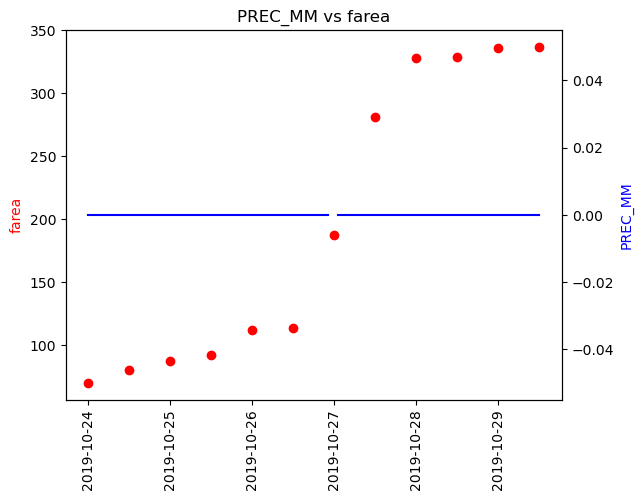

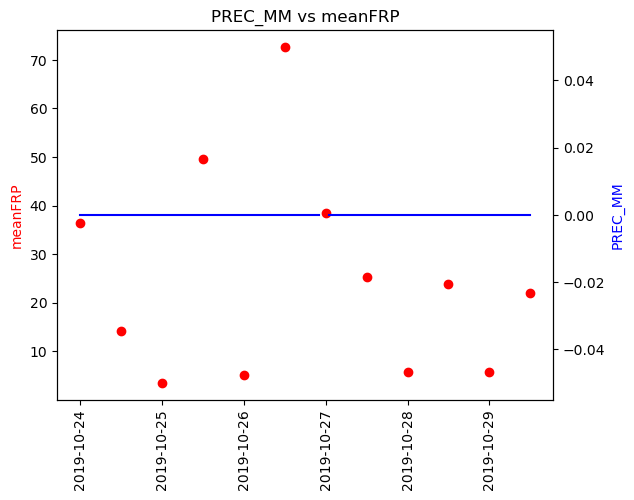

In [13]:
met = ['TEMP_C', 'RH_PERC', ' VPD_HPA', 'WDSPD_KPH',
       'FWI', 'PREC_MM']  ## Station Data Columns to Plot
fire = [ 'farea','meanFRP',] ## FEDS columns to plot

#n_met = len(met)
#n_fire = len(fire)

for m in met:
    for f in fire:
        fig, ax = plt.subplots()
        
        ax.scatter(full_fr["t"], full_fr[f], color = "r")
        #ax.plot(full_fr["t"], full_fr[m])
        #plt.xticks(rotation = 90)   
        ax.set_title(m + " vs " +  f)
        ax.set_ylabel(f, color = "red")
        ax2=ax.twinx()
        ax2.plot(full_fr["t"], full_fr[m],color="blue")
        ax2.set_ylabel(m,color="blue")
        ax.tick_params(axis='x', labelrotation = 90)

        plt.show()